# MOMARL Results Visualization

Visualize Multi-Objective Multi-Agent RL training results from WandB logs.

**Features:** Pareto front, hypervolume comparison, hypervolume learning curve

## 1. Configuration

In [1]:
from pathlib import Path

# Paths
RESULTS_DIR = Path("../../momarl_results/100_weights")
OUTPUT_DIR = Path("./figures")

# Hypervolume reference point (origin for maximization)
HYPERVOLUME_REF_POINT = [0.0, 0.0]

# Objective names for axis labels
OBJECTIVE_NAMES = ["inverse_global_temperature", "global_economic_output"]

# Plot settings
FIGURE_DPI = 150
SAVE_FIGURES = True

# Filter runs with returns below these thresholds (set to None to disable)
MIN_RETURN_OBJ_0 = 10.0
MIN_RETURN_OBJ_1 = 10.0

# WandB settings
USE_WANDB_API = True
WANDB_PROJECT = "harl_justice_momarl"
WANDB_ENTITY = "olaandrasz-tu-delft"

## 2. Imports

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings

# Hypervolume (DEAP)
try:
    from deap.tools._hypervolume import hv
    HV_AVAILABLE = True
except ImportError:
    HV_AVAILABLE = False
    warnings.warn("DEAP not installed - hypervolume unavailable")

# WandB
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False
    warnings.warn("wandb not installed")

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"HV: {HV_AVAILABLE}, WandB: {WANDB_AVAILABLE}")

if WANDB_AVAILABLE and USE_WANDB_API:
    try:
        wandb.login()
        print("WandB login successful")
    except Exception as e:
        print(f"WandB login failed: {e}")

HV: True, WandB: True


wandb: Currently logged in as: olaandrasz (olaandrasz-tu-delft) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB login successful


## 3. Data Loading

In [3]:
@dataclass
class RunData:
    """Container for a single WandB run."""
    run_id: str
    algorithm: str
    weights: List[float]
    weight_idx: int
    return_obj_0: float
    return_obj_1: float
    vector_return: List[float]
    timestamp: str
    total_steps: int


def load_json(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    with open(path, 'r') as f:
        return json.load(f)


def extract_algorithm(metadata: Dict) -> str:
    """Extract algorithm name from wandb metadata args."""
    args = metadata.get("args", [])
    for i, arg in enumerate(args):
        if arg == "--algo" and i + 1 < len(args):
            return args[i + 1].upper()
    return "UNKNOWN"


def parse_run(run_dir: Path) -> Optional[RunData]:
    """Parse a single WandB run directory."""
    metadata = load_json(run_dir / "files" / "wandb-metadata.json")
    summary = load_json(run_dir / "files" / "wandb-summary.json")
    
    if metadata is None or summary is None:
        return None
    
    run_name = run_dir.name
    parts = run_name.split("-")
    
    return RunData(
        run_id=parts[-1] if len(parts) > 1 else run_name,
        algorithm=extract_algorithm(metadata),
        weights=summary.get("weights", [0.5, 0.5]),
        weight_idx=summary.get("weight_idx", -1),
        return_obj_0=summary.get("return_obj_0") or summary.get("final/return_obj_0") or 0.0,
        return_obj_1=summary.get("return_obj_1") or summary.get("final/return_obj_1") or 0.0,
        vector_return=summary.get("vector_return") or summary.get("final/vector_return") or [0.0, 0.0],
        timestamp=parts[1] if len(parts) > 1 else "",
        total_steps=summary.get("total_num_steps", 0)
    )


def load_all_runs(results_dir: Path) -> List[RunData]:
    """Load all WandB runs from a directory."""
    run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and d.name.startswith("run-")])
    runs = [parse_run(d) for d in run_dirs]
    return [r for r in runs if r is not None]


def runs_to_dataframe(runs: List[RunData]) -> pd.DataFrame:
    """Convert RunData list to DataFrame."""
    return pd.DataFrame([{
        "run_id": r.run_id,
        "algorithm": r.algorithm,
        "weight_0": r.weights[0] if r.weights else 0.0,
        "weight_1": r.weights[1] if len(r.weights) > 1 else 0.0,
        "weight_idx": r.weight_idx,
        "return_obj_0": r.return_obj_0,
        "return_obj_1": r.return_obj_1,
        "timestamp": r.timestamp,
        "total_steps": r.total_steps,
    } for r in runs])

## 4. Load Runs

In [4]:
runs = load_all_runs(RESULTS_DIR)
df = runs_to_dataframe(runs)

# Filter failed runs
original_count = len(df)
if MIN_RETURN_OBJ_0:
    df = df[df["return_obj_0"] >= MIN_RETURN_OBJ_0]
if MIN_RETURN_OBJ_1:
    df = df[df["return_obj_1"] >= MIN_RETURN_OBJ_1]

if len(df) < original_count:
    print(f"Filtered {original_count - len(df)} runs below threshold")

print(f"Loaded {len(df)} runs from {RESULTS_DIR}")
print(df["algorithm"].value_counts())
df.head(10)

Filtered 10 runs below threshold
Loaded 207 runs from ../../momarl_results/100_weights
algorithm
HAPPO    105
MAPPO    102
Name: count, dtype: int64


,run_id,algorithm,weight_0,weight_1,weight_idx,return_obj_0,return_obj_1,timestamp,total_steps
0,fbtodde2,HAPPO,0.000000,1.000000,0,81.644737,359.682728,20260224_171050,2508000
1,kmw9657e,MAPPO,0.000000,1.000000,0,88.115180,370.059218,20260224_171050,2508000
2,l9prn4r3,MAPPO,1.000000,0.000000,0,150.608806,278.737636,20260224_171428,1425000
3,dk24lv3e,HAPPO,1.000000,0.000000,0,159.696440,292.004088,20260224_171434,1425000
4,9a1e6bkp,HAPPO,0.009973,0.990027,1,84.166590,367.182500,20260224_183539,2508000
5,4acq42yi,MAPPO,0.009973,0.990027,1,84.663859,346.843314,20260224_192503,2508000
6,t7bj1r92,HAPPO,0.019963,0.980037,2,82.924211,362.738927,20260224_194955,2508000
7,biphwokq,HAPPO,0.029984,0.970016,3,83.524118,360.875429,20260224_210708,2508000
8,u1604dyb,MAPPO,0.019963,0.980037,2,84.008813,351.300823,20260224_213605,2508000
9,qb5ryk3e,HAPPO,0.040072,0.959928,4,85.451250,360.626295,20260224_222337,2508000


## 5. Pareto Front

In [20]:
COLORS = {"HAPPO": "#1f77b4", "MAPPO": "#ff7f0e", "UNKNOWN": "#7f7f7f"}
MARKERS = {"HAPPO": "o", "MAPPO": "s", "UNKNOWN": "^"}

# Plotly markers (different naming)
PLOTLY_MARKERS = {"HAPPO": "circle", "MAPPO": "square", "UNKNOWN": "triangle-up"}

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed - interactive plots unavailable")


def is_pareto_efficient(points: np.ndarray) -> np.ndarray:
    """Return boolean mask of Pareto-efficient points (maximization)."""
    n = len(points)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                is_efficient[i] = False
                break
    return is_efficient


def plot_pareto_front_interactive(df: pd.DataFrame) -> go.Figure:
    """Plot interactive Pareto front with hover info (weight, run_id).
    Includes checkbox to show/hide dominated (non-Pareto) points."""
    fig = go.Figure()
    
    algos = list(df["algorithm"].unique())
    dominated_trace_indices = []  # Track indices of dominated point traces
    trace_idx = 0
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo].reset_index(drop=True)
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color = COLORS.get(algo, "#333")
        marker = PLOTLY_MARKERS.get(algo, "circle")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        non_pareto_mask = ~pareto_mask
        
        # Create hover text with weight and run_id
        hover_text = [
            f"Run: {row['run_id']}<br>Weight: ({row['weight_0']:.2f}, {row['weight_1']:.2f})<br>"
            f"{OBJECTIVE_NAMES[0]}: {row['return_obj_0']:.2f}<br>{OBJECTIVE_NAMES[1]}: {row['return_obj_1']:.2f}"
            for _, row in algo_df.iterrows()
        ]
        
        # Add dominated (non-Pareto) points first (faded, hidden by default)
        if non_pareto_mask.any():
            non_pareto_df = algo_df[non_pareto_mask]
            non_pareto_hover = [hover_text[i] for i in range(len(algo_df)) if non_pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=non_pareto_df["return_obj_0"],
                y=non_pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=10, color=color, symbol=marker, opacity=0.4,
                           line=dict(width=1, color="gray")),
                name=f"{algo} (dominated)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=non_pareto_hover,
                visible=False  # Hidden by default
            ))
            dominated_trace_indices.append(trace_idx)
            trace_idx += 1
        
        # Add Pareto points (highlighted)
        if pareto_mask.any():
            pareto_df = algo_df[pareto_mask]
            pareto_hover = [hover_text[i] for i in range(len(algo_df)) if pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=pareto_df["return_obj_0"],
                y=pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=14, color=color, symbol=marker, 
                           line=dict(width=2, color="black")),
                name=f"{algo} (Pareto)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=pareto_hover
            ))
            trace_idx += 1
    
    # Create visibility arrays for toggle buttons
    n_traces = len(fig.data)
    # Pareto only: dominated traces hidden
    pareto_only_visible = [True] * n_traces
    for i in dominated_trace_indices:
        pareto_only_visible[i] = False
    
    # All points: everything visible
    all_visible = [True] * n_traces
    
    fig.update_layout(
        title=dict(text="Pareto Front: HAPPO vs MAPPO", font=dict(size=16, weight="bold")),
        xaxis_title=OBJECTIVE_NAMES[0].replace('_', ' ').title(),
        yaxis_title=OBJECTIVE_NAMES[1].replace('_', ' ').title(),
        legend=dict(x=0.98, y=0.98, xanchor="right", yanchor="bottom"),
        hovermode="closest",
        width=900,
        height=650,
        # Add toggle buttons
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=[
                    dict(
                        args=[{"visible": pareto_only_visible}],
                        label="Pareto Only",
                        method="update"
                    ),
                    dict(
                        args=[{"visible": all_visible}],
                        label="Show All Points",
                        method="update"
                    ),
                ],
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.0,
                xanchor="left",
                y=1.12,
                yanchor="top"
            ),
        ]
    )
    
    return fig


def plot_pareto_front(df: pd.DataFrame, show_weights: bool = True) -> plt.Figure:
    """Plot Pareto front comparison between algorithms (static matplotlib)."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for algo in df["algorithm"].unique():
        algo_df = df[df["algorithm"] == algo]
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color, marker = COLORS.get(algo, "#333"), MARKERS.get(algo, "x")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        
        # Pareto (highlighted)
        if pareto_mask.any():
            ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='black', linewidths=1.5, label=f"{algo} (Pareto)")
        
        # Weight annotations
        if show_weights:
            for _, row in algo_df.iterrows():
                ax.annotate(f"({row['weight_0']:.2f}, {row['weight_1']:.2f})",
                           (row["return_obj_0"], row["return_obj_1"]),
                           textcoords="offset points", xytext=(5, 5 if algo == "HAPPO" else -12),
                           fontsize=7, color=color, alpha=0.8)
    
    ax.set_xlabel(OBJECTIVE_NAMES[0].replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(OBJECTIVE_NAMES[1].replace('_', ' ').title(), fontsize=12)
    ax.set_title("Pareto Front: HAPPO vs MAPPO", fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

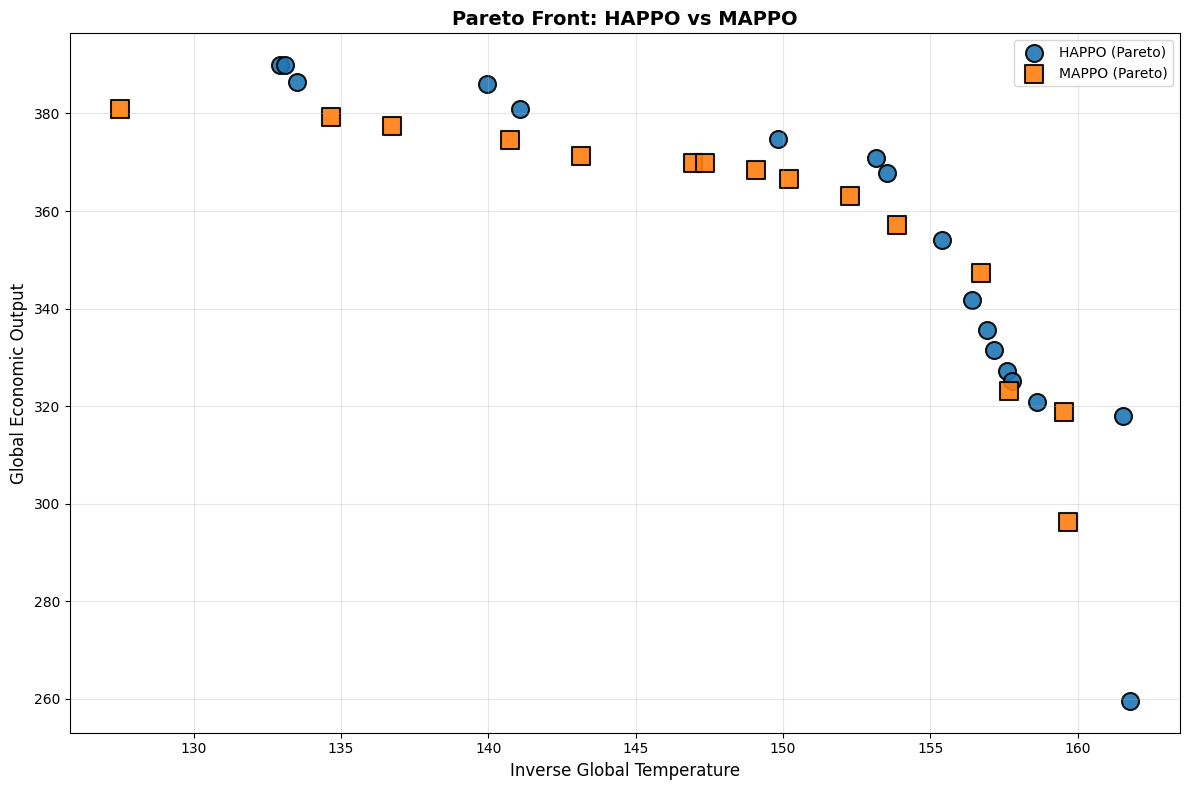

In [21]:
# Interactive plot with hover (Plotly)
if PLOTLY_AVAILABLE:
    fig_pareto_interactive = plot_pareto_front_interactive(df)
    fig_pareto_interactive.show()
else:
    print("Plotly not available, showing static plot")

# Static plot (matplotlib) - for saving
fig_pareto = plot_pareto_front(df, show_weights=False)
if SAVE_FIGURES:
    fig_pareto.savefig(OUTPUT_DIR / "pareto_front.png", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

## 6. Hypervolume Over Time

In [ ]:
def compute_hypervolume(points: np.ndarray, ref_point: List[float]) -> float:
    """Compute hypervolume for points (maximization). DEAP assumes minimization, so we negate."""
    if not HV_AVAILABLE or len(points) == 0:
        return 0.0
    
    ref = np.array(ref_point)
    #ref = np.array([120, 350])
    valid_mask = np.all(points > ref, axis=1)
    if not valid_mask.any():
        return 0.0
    
    # Negate for DEAP (minimization)
    return hv.hypervolume((-points[valid_mask]).tolist(), (-ref).tolist())


def fetch_training_history_from_wandb(runs_df, entity: str, project: str) -> Dict[str, pd.DataFrame]:
    """Fetch training history for all runs from WandB API.
    Returns histories dict with algorithm info embedded in each DataFrame."""
    api = wandb.Api()
    
    histories = {}
    i = 0 
    for run_id, algorithm in zip(runs_df["run_id"], runs_df["algorithm"]):
        if i % 50 == 0:
            print(f"Fetching history for run {i}/{len(runs_df)}")
        i += 1
        try:
            online_data = api.run(f"{entity}/{project}/{run_id}")
        except Exception as e:
            print(f"Failed to fetch run {run_id}")
            continue
        #print(f"Fetching run {run_id}")
        if "summary" in online_data.name.lower():
            continue
        
        zero_df = online_data.history(keys=["0"])
        one_df = online_data.history(keys=["1"])
        steps_df = online_data.history(keys=["total_num_steps"])
        history_df = pd.DataFrame({
            "run_id": run_id,
            "algorithm": algorithm,
            "total_num_steps": steps_df["total_num_steps"],
            "0": zero_df["0"],
            "1": one_df["1"]
        })
        
        histories[run_id] = history_df
    return histories


def compute_hypervolume_over_time(histories: Dict[str, pd.DataFrame],
                                   ref_point: List[float], num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Compute hypervolume at each time bin for each algorithm with mean and std.
    
    At each timestep, for each run:
    1. Collects points logged up to that timestep for that run
    2. Computes hypervolume for that run
    3. Aggregates mean and std across all runs
    
    Returns dict: algo -> (steps, mean_hv, std_hv)
    """
    if not HV_AVAILABLE:
        return {}
    
    # Group histories by algorithm (extracted from DataFrame)
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        algo = hist["algorithm"].iloc[0] if len(hist) > 0 else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)
    
    results = {}
    for algo, hist_list in algo_histories.items():
        # Collect ALL data points: (steps, obj_0, obj_1) from all runs
        all_data = []
        for hist in hist_list:
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            for _, row in valid_rows.iterrows():
                all_data.append((row["total_num_steps"], row["0"], row["1"]))
        
        if not all_data:
            continue
        
        all_data.sort(key=lambda x: x[0])
        max_steps = int(all_data[-1][0])
        
        # Compute HV at each timestep
        hv_values, step_centers = [], []
        
        for i in range(num_bins):
            threshold = int(max_steps * (i + 1) / num_bins)
            # Collect ALL points up to this threshold
            points = np.array([[d[1], d[2]] for d in all_data if d[0] <= threshold])
            
            if len(points) > 0:
                try:
                    # Compute hypervolume on Pareto front
                    hv_val = compute_hypervolume(points, ref_point)
                    hv_values.append(hv_val)
                    step_centers.append(threshold)
                except Exception:
                    pass
        
        if hv_values:
            results[algo] = (np.array(step_centers), np.array(hv_values))
    
    return results


def plot_hypervolume_over_time(hv_over_time: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot hypervolume learning curves with standard deviation bands."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in hv_over_time.items():
        steps, hv_mean, hv_std = data
        color = COLORS.get(algo, "#333")
        
        # Plot mean line
        ax.plot(steps, hv_mean, color=color, linewidth=2, label=algo)
        
        # Plot std as transparent band
        ax.fill_between(steps, hv_mean - hv_std, hv_mean + hv_std, 
                        color=color, alpha=0.2)
        
        # Annotate final value
        ax.annotate(f'{hv_mean[-1]:.0f} ± {hv_std[-1]:.0f}', 
                   xy=(steps[-1], hv_mean[-1]), xytext=(5, 0),
                   textcoords='offset points', fontsize=9, color=color)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Hypervolume")
    ax.set_title(f"Hypervolume Over Training (ref={HYPERVOLUME_REF_POINT})", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

In [14]:
if WANDB_AVAILABLE and USE_WANDB_API and HV_AVAILABLE:
    print("Fetching from WandB API...")
    histories = fetch_training_history_from_wandb(df, WANDB_ENTITY, WANDB_PROJECT)
    
    # Extract algorithms from histories
    algos_found = {hist["algorithm"].iloc[0] for hist in histories.values() if len(hist) > 0}
    print(f"\nLoaded {len(histories)} runs, algorithms: {algos_found}")

Fetching from WandB API...
Fetching history for run 0/207
Fetching history for run 10/207
Fetching history for run 20/207
Fetching history for run 30/207
Fetching history for run 40/207
Failed to fetch run dobl793l
Failed to fetch run e5zbjc3v
Failed to fetch run dpc9iovh
Fetching history for run 50/207
Failed to fetch run ayryak54
Failed to fetch run y1ys0f6l
Failed to fetch run o3nitmfd
Failed to fetch run 9cnbqes2
Failed to fetch run wibcbzte
Failed to fetch run 1ikfxulr
Failed to fetch run hosbifb8
Failed to fetch run 5qvezhwu
Failed to fetch run eujmvrg7
Failed to fetch run 05mqq7vm
Fetching history for run 60/207
Failed to fetch run k8tcmudx
Failed to fetch run 32dhqtc7
Failed to fetch run bxba279x
Failed to fetch run igr9s82f
Fetching history for run 70/207
Fetching history for run 80/207
Fetching history for run 90/207
Fetching history for run 100/207
Fetching history for run 110/207
Fetching history for run 120/207
Fetching history for run 130/207
Fetching history for run 140/

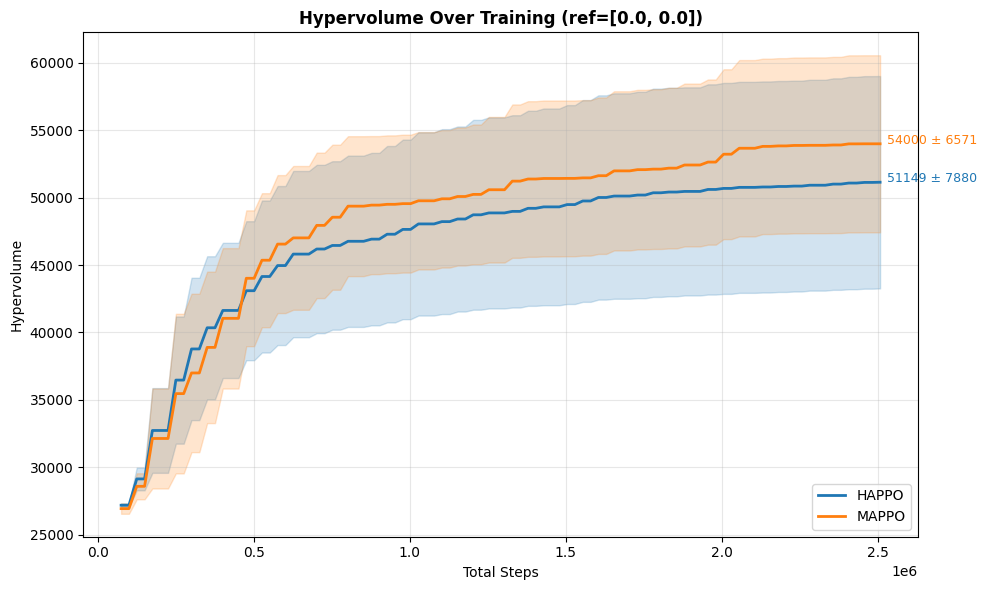

In [17]:
hv_over_time = compute_hypervolume_over_time(histories, HYPERVOLUME_REF_POINT)

if hv_over_time:
    fig_hv_time = plot_hypervolume_over_time(hv_over_time)
    if SAVE_FIGURES:
        fig_hv_time.savefig(OUTPUT_DIR / "hypervolume_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for HV over time")


## 7. Summary

In [10]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

for algo in df["algorithm"].unique():
    algo_df = df[df["algorithm"] == algo]
    points = algo_df[["return_obj_0", "return_obj_1"]].values
    pareto_count = is_pareto_efficient(points).sum()
    
    print(f"\n{algo} ({len(algo_df)} runs, {pareto_count} Pareto):")
    for i, name in enumerate(OBJECTIVE_NAMES):
        col = f"return_obj_{i}"
        print(f"  {name}: {algo_df[col].mean():.2f} ± {algo_df[col].std():.2f} [{algo_df[col].min():.2f}, {algo_df[col].max():.2f}]")

print("\n" + "=" * 60)
df.sort_values(["algorithm", "weight_idx"])

SUMMARY STATISTICS

HAPPO (105 runs, 17 Pareto):
  inverse_global_temperature: 134.90 ± 22.55 [81.64, 161.76]
  global_economic_output: 353.72 ± 28.68 [257.78, 389.92]

MAPPO (102 runs, 15 Pareto):
  inverse_global_temperature: 136.39 ± 21.36 [84.01, 159.68]
  global_economic_output: 353.68 ± 19.35 [278.74, 380.90]



,run_id,algorithm,weight_0,weight_1,weight_idx,return_obj_0,return_obj_1,timestamp,total_steps
0,fbtodde2,HAPPO,0.000000,1.000000,0,81.644737,359.682728,20260224_171050,2508000
3,dk24lv3e,HAPPO,1.000000,0.000000,0,159.696440,292.004088,20260224_171434,1425000
23,zm33ob1p,HAPPO,0.100278,0.899722,0,97.314156,372.330537,20260225_113812,2508000
65,32dhqtc7,HAPPO,0.251196,0.748804,0,124.759415,379.055416,20260226_145258,2508000
66,bxba279x,HAPPO,0.301663,0.698337,0,131.344912,369.334366,20260226_145258,2508000
...,...,...,...,...,...,...,...,...,...
21,k4lez3jd,MAPPO,0.080190,0.919810,8,88.659242,358.371270,20260225_100933,2508000
135,uy2ydvmd,MAPPO,0.685527,0.314473,8,148.805709,355.609177,20260227_125408,2508000
138,v2zamdvb,MAPPO,0.483638,0.516362,8,149.065547,368.510641,20260227_133936,2508000
189,caaua9cy,MAPPO,0.989899,0.010101,8,153.405182,305.470109,20260228_125656,2508000
